# Predicting war events

## I. Importing essential libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string

import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm.notebook import tqdm
from tqdm import tqdm
import pymorphy3

import os
from pathlib import Path
import json

## II. Importing datasets

In [2]:
weather = pd.read_csv("../data/all_weather_by_hour_2023-2025_v1.csv")

In [3]:
df_war_events_raw = pd.read_csv("../data/alarms-240222-010325.csv", sep=";")
df_regions = pd.read_csv("../data/regions.csv")

In [4]:
json_path_isw = Path("../data/isw_reports_v2.json")

with open(json_path_isw, "r", encoding="utf-8") as f:
    data = json.load(f)

df_isw_raw = pd.DataFrame(data)

print(type(df_isw_raw))

<class 'pandas.core.frame.DataFrame'>


In [5]:
json_path_tg = Path("../data/telegram_data.json")

with open(json_path_tg, "r", encoding="utf-8") as f:
    data = json.load(f)

df_tg_raw = pd.DataFrame(data)

print(type(df_tg_raw))

<class 'pandas.core.frame.DataFrame'>


## III. EDA

### Weather

In [6]:
pd.set_option("display.max_columns", None)
weather.head()

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations
0,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,00:00:00,1645653600,2.4,-1.6,89.18,0.8,0.0,0.0,0.1,0.2,['snow'],31.3,15.5,275.6,1020.0,0.0,91.5,0.0,NaN,0.0,Overcast,snow,obs,remote
1,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,01:00:00,1645657200,2.4,-1.5,87.90,0.6,0.0,0.0,0.0,0.2,['snow'],27.7,14.8,280.3,1021.0,0.2,88.2,0.0,NaN,0.0,Partially cloudy,fog,obs,remote
2,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,02:00:00,1645660800,2.9,-0.8,88.58,1.2,0.0,0.0,0.0,0.1,['snow'],29.2,14.4,310.0,1022.0,10.0,100.0,NaN,NaN,NaN,Overcast,cloudy,obs,33177099999
3,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,03:00:00,1645664400,2.3,-1.3,86.63,0.3,0.0,0.0,0.0,0.1,['snow'],23.8,13.3,295.1,1021.0,0.1,92.0,0.0,NaN,0.0,Overcast,fog,obs,remote
4,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,04:00:00,1645668000,1.9,-1.8,87.85,0.1,0.0,0.0,0.0,0.1,['snow'],24.5,13.3,305.8,1021.0,0.0,93.8,0.0,NaN,0.0,Overcast,cloudy,obs,remote


In [7]:
weather.shape

(608304, 65)

In [8]:
weather['hour_datetime'].head(2000)

0       00:00:00
1       01:00:00
2       02:00:00
3       03:00:00
4       04:00:00
          ...   
1995    04:00:00
1996    05:00:00
1997    06:00:00
1998    07:00:00
1999    08:00:00
Name: hour_datetime, Length: 2000, dtype: object

In [9]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608304 entries, 0 to 608303
Data columns (total 65 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   city_latitude         608304 non-null  float64
 1   city_longitude        608304 non-null  float64
 2   city_resolvedAddress  608304 non-null  object 
 3   city_address          608304 non-null  object 
 4   city_timezone         608304 non-null  object 
 5   city_tzoffset         608304 non-null  float64
 6   day_datetime          608304 non-null  object 
 7   day_datetimeEpoch     608304 non-null  int64  
 8   day_tempmax           608304 non-null  float64
 9   day_tempmin           608304 non-null  float64
 10  day_temp              608304 non-null  float64
 11  day_feelslikemax      608304 non-null  float64
 12  day_feelslikemin      608304 non-null  float64
 13  day_feelslike         608304 non-null  float64
 14  day_dew               608304 non-null  float64
 15  

In [10]:
weather.describe()

,city_latitude,city_longitude,city_tzoffset,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunriseEpoch,day_sunsetEpoch,day_moonphase,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex
count,608304.000000,608304.000000,608304.0,6.083040e+05,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,552952.000000,607752.000000,607752.000000,607752.000000,6.083040e+05,6.083040e+05,608304.000000,6.083040e+05,608304.000000,608304.000000,608304.000000,608304.000000,608202.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.00000,331846.000000,608304.000000,603968.000000,521042.000000,603968.000000
mean,49.143238,30.142514,2.0,1.693217e+09,15.203232,6.253993,10.721077,14.287248,4.267318,9.254504,5.285646,72.891185,2.095628,53.533924,6.553061,0.121132,0.598356,34.879037,18.545700,191.158465,1016.920939,64.812537,14.917199,141.953237,12.242466,4.806077,1.693240e+09,1.693284e+09,0.489195,1.693258e+09,10.719390,9.252908,72.891267,5.283823,0.087357,6.552809,0.005045,0.598141,23.769943,11.399938,189.830264,1016.91840,17.010448,64.811065,142.722294,0.595017,1.413903
std,1.337209,4.303973,0.0,2.748558e+07,10.592473,8.162055,9.207622,11.577354,9.929590,10.713666,7.473743,14.564090,10.685616,49.874998,12.103297,0.662849,1.998581,11.736481,6.887631,106.201073,8.446172,28.824705,7.753173,96.845076,8.371915,2.653499,2.748640e+07,2.748407e+07,0.289963,2.748559e+07,9.787529,11.293806,19.456422,7.652857,2.141735,24.745557,0.048299,2.615546,11.492758,6.517607,106.383976,8.68127,9.656796,37.318628,220.920973,0.828064,2.226545
min,46.472500,22.285100,2.0,1.645654e+09,-14.300000,-50.300000,-17.500000,-21.800000,-50.300000,-27.100000,-20.700000,23.300000,0.000000,0.000000,0.000000,0.000000,0.000000,6.100000,2.500000,0.000000,981.600000,0.000000,0.000000,0.000000,0.000000,0.000000,1.645676e+09,1.645715e+09,0.000000,1.645654e+09,-50.300000,-50.300000,8.460000,-25.900000,0.000000,0.000000,0.000000,0.000000,0.700000,0.000000,0.000000,973.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.292400,25.935500,2.0,1.669414e+09,5.900000,-0.200000,2.800000,3.800000,-3.800000,-0.100000,-0.300000,62.400000,0.000000,0.000000,0.000000,0.000000,0.000000,26.600000,14.000000,98.200000,1011.500000,43.900000,9.900000,51.200000,4.400000,2.000000,1.669441e+09,1.669472e+09,0.250000,1.669456e+09,2.400000,-0.300000,59.310000,-0.400000,0.000000,0.000000,0.000000,0.000000,14.800000,7.200000,98.000000,1011.20000,10.000000,30.000000,0.000000,0.000000,0.000000
50%,49.416800,30.737100,2.0,1.693256e+09,15.100000,6.100000,10.600000,15.100000,4.200000,9.900000,5.300000,74.200000,0.100000,100.000000,4.170000,0.000000,0.000000,33.800000,18.000000,195.600000,1016.500000,70.700000,12.500000,129.400000,11.200000,5.000000,1.693277e+09,1.693326e+09,0.500000,1.693258e+09,10.200000,10.200000,77.430000,5.300000,0.000000,0.000000,0.000000,0.000000,22.300000,10.800000,191.900000,1016.60000,15.800000,80.000000,5.600000,0.100000,0.000000
75%,50.253600,34.551700,2.0,1.717016e+09,24.600000,13.200000,18.800000,24.600000,13.200000,18.800000,11.500000,84.800000,1.092000,100.000000,8.330000,0.000000,0.000000,41.400000,22.000000,287.000000,1022.000000,90.600000,20.000000,226.800000,19.600000,7.000000,1.717035e+09,1.717092e+09,0.750000,1.717060e+09,18.400000,18.400000,89.050000,11.500000,0.000000,0.

In [11]:
weather.isna().sum()

city_latitude              0
city_longitude             0
city_resolvedAddress       0
city_address               0
city_timezone              0
                        ... 
hour_uvindex            4336
hour_conditions            0
hour_icon                  0
hour_source                0
hour_stations              0
Length: 65, dtype: int64

In [12]:
weather.duplicated().sum()

np.int64(0)

In [13]:
weather["city_address"] = weather["city_address"].str.replace(",Ukraine", "")

In [14]:
weather['day_datetime'] = pd.to_datetime(weather['day_datetime'], errors="coerce")

weather["datetime_hour"] = (
    weather["day_datetime"] +
    pd.to_timedelta(weather["hour_datetime"].astype(str))
)

print(weather[["day_datetime", "hour_datetime", "datetime_hour"]].head())
print("NaT in datetime_hour:", weather["datetime_hour"].isna().sum())

  day_datetime hour_datetime       datetime_hour
0   2022-02-24      00:00:00 2022-02-24 00:00:00
1   2022-02-24      01:00:00 2022-02-24 01:00:00
2   2022-02-24      02:00:00 2022-02-24 02:00:00
3   2022-02-24      03:00:00 2022-02-24 03:00:00
4   2022-02-24      04:00:00 2022-02-24 04:00:00
NaT in datetime_hour: 0


In [15]:
weather["date"] = weather["datetime_hour"].dt.floor("D")
weather["hour"] = weather["datetime_hour"].dt.hour
weather["month"] = weather["datetime_hour"].dt.month
weather["weekday"] = weather["datetime_hour"].dt.weekday

In [16]:
weather = weather.drop(columns=[
    "day_stations",
    "day_source",
    "hour_source",
    "hour_icon",
    "hour_stations",
    "hour_datetimeEpoch",
    'hour_preciptype', 
    "hour_visibility",
    "day_visibility",
    'day_preciptype',
    "day_icon",
    "day_description",
    "day_datetimeEpoch",
    "day_sunriseEpoch",
    "day_sunsetEpoch",
    "city_resolvedAddress",
    "city_timezone",
    "city_tzoffset"
])

In [17]:
print(weather.shape)

(608304, 52)


In [18]:
weather.head()

,city_latitude,city_longitude,city_address,day_datetime,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunset,day_moonphase,day_conditions,hour_datetime,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,datetime_hour,date,hour,month,weekday
0,50.7469,25.3263,Lutsk,2022-02-24,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,36.9,2.8,1.0,07:13:36,17:51:06,0.77,"Snow, Partially cloudy",00:00:00,2.4,-1.6,89.18,0.8,0.0,0.0,0.1,0.2,31.3,15.5,275.6,1020.0,91.5,0.0,NaN,0.0,Overcast,2022-02-24 00:00:00,2022-02-24,0,2,3
1,50.7469,25.3263,Lutsk,2022-02-24,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,36.9,2.8,1.0,07:13:36,17:51:06,0.77,"Snow, Partially cloudy",01:00:00,2.4,-1.5,87.90,0.6,0.0,0.0,0.0,0.2,27.7,14.8,280.3,1021.0,88.2,0.0,NaN,0.0,Partially cloudy,2022-02-24 01:00:00,2022-02-24,1,2,3
2,50.7469,25.3263,Lutsk,2022-02-24,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,36.9,2.8,1.0,07:13:36,17:51:06,0.77,"Snow, Partially cloudy",02:00:00,2.9,-0.8,88.58,1.2,0.0,0.0,0.0,0.1,29.2,14.4,310.0,1022.0,100.0,NaN,NaN,NaN,Overcast,2022-02-24 02:00:00,2022-02-24,2,2,3
3,50.7469,25.3263,Lutsk,2022-02-24,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,36.9,2.8,1.0,07:13:36,17:51:06,0.77,"Snow, Partially cloudy",03:00:00,2.3,-1.3,86.63,0.3,0.0,0.0,0.0,0.1,23.8,13.3,295.1,1021.0,92.0,0.0,NaN,0.0,Overcast,2022-02-24 03:00:00,2022-02-24,3,2,3
4,50.7469,25.3263,Lutsk,2022-02-24,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,36.9,2.8,1.0,07:13:36,17:51:06,0.77,"Snow, Partially cloudy",04:00:00,1.9,-1.8,87.85,0.1,0.0,0.0,0.0,0.1,24.5,13.3,305.8,1021.0,93.8,0.0,NaN,0.0,Overcast,2022-02-24 04:00:00,2022-02-24,4,2,3


In [19]:
weather['day_solarradiation'] = weather['day_solarradiation'].fillna(weather['day_solarradiation'].median())
weather['day_solarenergy'] = weather['day_solarenergy'].fillna(weather['day_solarenergy'].median())
weather['day_uvindex'] = weather['day_uvindex'].fillna(weather['day_uvindex'].median())
weather['hour_solarradiation'] = weather['hour_solarradiation'].fillna(weather['hour_solarradiation'].median())
weather['hour_solarenergy'] = weather['hour_solarenergy'].fillna(weather['hour_solarenergy'].median())
weather['hour_uvindex'] = weather['hour_uvindex'].fillna(weather['hour_uvindex'].median())
weather['hour_precip'] = weather['hour_precip'].fillna(0)

In [20]:
weather.isna().sum()

city_latitude          0
city_longitude         0
city_address           0
day_datetime           0
day_tempmax            0
day_tempmin            0
day_temp               0
day_feelslikemax       0
day_feelslikemin       0
day_feelslike          0
day_dew                0
day_humidity           0
day_precip             0
day_precipprob         0
day_precipcover        0
day_snow               0
day_snowdepth          0
day_windgust           0
day_windspeed          0
day_winddir            0
day_pressure           0
day_cloudcover         0
day_solarradiation     0
day_solarenergy        0
day_uvindex            0
day_sunrise            0
day_sunset             0
day_moonphase          0
day_conditions         0
hour_datetime          0
hour_temp              0
hour_feelslike         0
hour_humidity          0
hour_dew               0
hour_precip            0
hour_precipprob        0
hour_snow              0
hour_snowdepth         0
hour_windgust          0
hour_windspeed         0


In [21]:
def simplify_weather(x):
    if 'Snow' in x:
        return 'Snow'
    if 'Rain' in x:
        return 'Rain'
    if 'Overcast' in x or 'cloudy' in x:
        return 'Cloudy'
    if 'Clear' in x:
        return 'Clear'
    if 'Fog' in x:
        return 'Fog'
    return 'Other'

weather['hour_conditions_simple'] = weather['hour_conditions'].apply(simplify_weather)
weather['day_conditions_simple'] = weather['day_conditions'].apply(simplify_weather)

print(weather["hour_conditions_simple"].value_counts())
print(weather["day_conditions_simple"].value_counts())

hour_conditions_simple
Cloudy    448725
Clear     119719
Rain       29542
Snow       10318
Name: count, dtype: int64
day_conditions_simple
Rain      232467
Cloudy    225677
Snow       93182
Clear      56978
Name: count, dtype: int64


In [22]:
weather = pd.get_dummies(weather, columns=['day_conditions_simple','hour_conditions_simple'])

In [23]:
weather[['day_conditions','hour_conditions']].nunique()

day_conditions     19
hour_conditions    16
dtype: int64

In [24]:
weather = weather.drop(columns=['day_tempmax','day_tempmin', 'hour_conditions', 'day_conditions'])

In [25]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608304 entries, 0 to 608303
Data columns (total 56 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   city_latitude                  608304 non-null  float64       
 1   city_longitude                 608304 non-null  float64       
 2   city_address                   608304 non-null  object        
 3   day_datetime                   608304 non-null  datetime64[ns]
 4   day_temp                       608304 non-null  float64       
 5   day_feelslikemax               608304 non-null  float64       
 6   day_feelslikemin               608304 non-null  float64       
 7   day_feelslike                  608304 non-null  float64       
 8   day_dew                        608304 non-null  float64       
 9   day_humidity                   608304 non-null  float64       
 10  day_precip                     608304 non-null  float64       
 11  

In [26]:
corr = weather.corr(numeric_only=True)

In [27]:
weather.shape

(608304, 56)

In [28]:
weather["city_name"] = (
    weather["city_address"].str.split(",").str[0].str.strip()
)

city_to_region = {
    "Vinnytsia": "Вінницька",
    "Lutsk": "Волинська",
    "Dnipro": "Дніпропетровська",
    "Donetsk": "Донецька",
    "Zhytomyr": "Житомирська",
    "Uzhhorod": "Закарпатська",
    "Zaporizhzhia": "Запорізька",
    "Ivano-Frankivsk": "Івано-Франківська",
    "Kyiv": "Київ",
    "Kropyvnytskyi": "Кіровоградська",
    "Luhansk": "Луганська",
    "Lviv": "Львівська",
    "Mykolaiv": "Миколаївська",
    "Odesa": "Одеська",
    "Poltava": "Полтавська",
    "Rivne": "Рівненська",
    "Sumy": "Сумська",
    "Ternopil": "Тернопільська",
    "Kharkiv": "Харківська",
    "Kherson": "Херсонська",
    "Khmelnytskyi": "Хмельницька",
    "Cherkasy": "Черкаська",
    "Chernivtsi": "Чернівецька",
    "Chernihiv": "Чернігівська",
    "Simferopol": "АР Крим"
}

weather["region_key"] = weather["city_name"].map(city_to_region)
region_id_map = df_regions.set_index("region")["region_id"].to_dict()
weather["region_id"] = weather["region_key"].map(region_id_map)
weather

,city_latitude,city_longitude,city_address,day_datetime,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunset,day_moonphase,hour_datetime,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,datetime_hour,date,hour,month,weekday,day_conditions_simple_Clear,day_conditions_simple_Cloudy,day_conditions_simple_Rain,day_conditions_simple_Snow,hour_conditions_simple_Clear,hour_conditions_simple_Cloudy,hour_conditions_simple_Rain,hour_conditions_simple_Snow,city_name,region_key,region_id
0,50.7469,25.3263,Lutsk,2022-02-24,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,36.9,2.8,1.0,07:13:36,17:51:06,0.77,00:00:00,2.4,-1.6,89.18,0.8,0.0,0.0,0.1,0.2,31.3,15.5,275.6,1020.0,91.5,0.0,0.1,0.0,2022-02-24 00:00:00,2022-02-24,0,2,3,False,False,False,True,False,True,False,False,Lutsk,Волинська,3.0
1,50.7469,25.3263,Lutsk,2022-02-24,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,36.9,2.8,1.0,07:13:36,17:51:06,0.77,01:00:00,2.4,-1.5,87.90,0.6,0.0,0.0,0.0,0.2,27.7,14.8,280.3,1021.0,88.2,0.0,0.1,0.0,2022-02-24 01:00:00,2022-02-24,1,2,3,False,False,False,True,False,True,False,False,Lutsk,Волинська,3.0
2,50.7469,25.3263,Lutsk,2022-02-24,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,36.9,2.8,1.0,07:13:36,17:51:06,0.77,02:00:00,2.9,-0.8,88.58,1.2,0.0,0.0,0.0,0.1,29.2,14.4,310.0,1022.0,100.0,5.6,0.1,0.0,2022-02-24 02:00:00,2022-02-24,2,2,3,False,False,False,True,False,True,False,False,Lutsk,Волинська,3.0
3,50.7469,25.3263,Lutsk,2022-02-24,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,36.9,2.8,1.0,07:13:36,17:51:06,0.77,03:00:00,2.3,-1.3,86.63,0.3,0.0,0.0,0.0,0.1,23.8,13.3,295.1,1021.0,92.0,0.0,0.1,0.0,2022-02-24 03:00:00,2022-02-24,3,2,3,False,False,False,True,False,True,False,False,Lutsk,Волинська,3.0
4,50.7469,25.3263,Lutsk,2022-02-24,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,36.9,2.8,1.0,07:13:36,17:51:06,0.77,04:00:00,1.9,-1.8,87.85,0.1,0.0,0.0,0.0,0.1,24.5,13.3,305.8,1021.0,93.8,0.0,0.1,0.0,2022-02-24 04:00:00,2022-02-24,4,2,3,False,False,False,True,False,True,False,False,Lutsk,Волинська,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608299,49.5879,34.5517,Poltava,2025-03-01,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.000,0.0,0.00,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,106.1,9.2,4.0,06:24:29,17:24:37,0.05,19:00:00,-1.3,-3.5,73.09,-5.5,0.0,0.0,0.0,2.0,11.5,5.8,174.9,1030.0,100.0,0.0,0.0,0.0,2025-03-01 19:00:00,2025-03-01,19,3,5,False,True,False,False,False,True,False,False,Poltava,Полтавська,16.0
608300,49.5879,34.5517,Poltava,2025-03-01,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.000,0.0,0.00,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,106.1,9.2,4.0,06:24:29,17:24:37,0.05,20:00:00,-1.8,-1.8,81.17,-4.6,0.0,0.0,0.0,2.0,13.0,0.0,170.5,1029.6,100.0,0.0,0.0,0.0,2025-03-01 20:00:00,2025-03-01,20,3,5,False,True,False,False,False,True,False,False,Poltava,Полтавська,16.0
608301,49.5879,34.5517,Poltava,2025-03-01,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.000,0.0,0.00,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,106.1,9.2,4.0,06:24:29,17:24:37,0.05,21:00:00,-1.0,-3.5,68.31,-6.1,0.0,0.0,0.0,2.0,11.9,6.8,168.7,1029.0,99.6,0.0,0.0,0.0,2025-03-01 21:00:00,2025-03-01,21,3,5,False,True,False,False,False,True,False,False,Poltava,Полтавська,16.0
608302,49.5879,34.5517,Poltava,2025-03-01,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.000,0.0,0.00,0.0,2.0,26.6,12.2,164.8,1030.4,91.1

### War events (alarms)

In [29]:
df_war_events_raw.shape

(55788, 6)

In [30]:
df_war_events_raw.head()

,id,region_id,region_city,all_region,start,end
0,52432,12,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28
1,53292,23,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43
2,52080,3,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42
3,52857,19,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47
4,52700,18,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19


In [31]:
df_war_events_raw.sample(5)

,id,region_id,region_city,all_region,start,end
33979,134500,5,Донецька обл.,1,2024-02-27 16:37:54,2024-02-27 17:02:19
8858,60390,8,Запорізька обл.,1,2022-08-17 06:26:48,2022-08-17 06:42:34
936,1249,4,Дніпропетровська обл.,1,2022-03-14 08:40:51,2022-03-14 09:25:47
44401,146123,23,Чернігівська обл.,1,2024-08-03 22:57:47,2024-08-03 23:33:47
52365,154673,16,Рівненська обл.,1,2024-12-25 10:05:41,2024-12-25 10:20:00


In [32]:
df_war_events_raw.describe()

,id,region_id,all_region
count,55788.000000,55788.000000,55788.000000
mean,109103.029935,12.178121,0.972180
std,38574.559928,6.474089,0.164457
min,1.000000,1.000000,0.000000
25%,68259.750000,6.000000,1.000000
50%,126918.500000,13.000000,1.000000
75%,143399.250000,19.000000,1.000000
max,158665.000000,25.000000,1.000000


In [33]:
df_war_events_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55788 entries, 0 to 55787
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           55788 non-null  int64 
 1   region_id    55788 non-null  int64 
 2   region_city  55788 non-null  object
 3   all_region   55788 non-null  int64 
 4   start        55788 non-null  object
 5   end          55788 non-null  object
dtypes: int64(3), object(3)
memory usage: 2.6+ MB


In [34]:
print("Missing values:\n", df_war_events_raw.isna().sum())
print("\nDuplicate rows:", df_war_events_raw.duplicated().sum())
print("Duplicate id:", df_war_events_raw.duplicated(subset=["id"]).sum())

Missing values:
 id             0
region_id      0
region_city    0
all_region     0
start          0
end            0
dtype: int64

Duplicate rows: 0
Duplicate id: 0


In [35]:
df_war_events_raw[df_war_events_raw["all_region"] == 0]["region_city"].value_counts()

region_city
Київ    1552
Name: count, dtype: int64

In [36]:
df_war_events = df_war_events_raw.copy()

In [37]:
df_war_events["start"] = pd.to_datetime(df_war_events["start"], errors="coerce")
df_war_events["end"] = pd.to_datetime(df_war_events["end"], errors="coerce")

print("Invalid start dates:", df_war_events["start"].isna().sum())
print("Invalid end dates:", df_war_events["end"].isna().sum())

print(df_war_events[["start", "end"]].dtypes)

Invalid start dates: 0
Invalid end dates: 0
start    datetime64[ns]
end      datetime64[ns]
dtype: object


In [38]:
print("Min start:", df_war_events["start"].min())
print("Max start:", df_war_events["start"].max())

print("Min end:", df_war_events["end"].min())
print("Max end:", df_war_events["end"].max())

Min start: 2022-02-24 07:43:17
Max start: 2025-03-01 23:26:07
Min end: 2022-02-24 09:52:28
Max end: 2025-03-02 02:44:07


In [39]:
df_war_events["duration_min"] = (df_war_events["end"] - df_war_events["start"]).dt.total_seconds() / 60

print(df_war_events["duration_min"].describe())

count    55788.000000
mean        72.798103
std         93.094316
min       -781.700000
25%         26.566667
50%         39.733333
75%         84.716667
max       3031.300000
Name: duration_min, dtype: float64


In [40]:
print("Negative durations:", (df_war_events["duration_min"] < 0).sum())
print("Zero durations:", (df_war_events["duration_min"] == 0).sum())

Negative durations: 1
Zero durations: 0


In [41]:
df_war_events[df_war_events["duration_min"] < 0]

,id,region_id,region_city,all_region,start,end,duration_min
47970,150000,17,Сумська обл.,1,2024-10-01 20:53:04,2024-10-01 07:51:22,-781.7


One anomalous record with a **negative duration** was found

In [42]:
df_war_events["region_key"] = (
    df_war_events["region_city"]
    .str.replace(" обл.", "")
    .replace({"Крим": "АР Крим"})
)

In [43]:
df_war_events.head()

,id,region_id,region_city,all_region,start,end,duration_min,region_key
0,52432,12,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28,129.183333,Львівська
1,53292,23,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43,191.000000,Чернігівська
2,52080,3,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42,30.000000,Вінницька
3,52857,19,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47,48.000000,Харківська
4,52700,18,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19,420.716667,Тернопільська


In [44]:
alarm_regions = sorted(df_war_events[df_war_events["all_region"] == 1]["region_key"].unique())

regions = df_regions["region"]

missing_in_alarms = sorted(set(regions) - set(alarm_regions))
extra_in_alarms = sorted(set(alarm_regions) - set(regions))

print("Missing regions in alarms:", missing_in_alarms)
print("Extra regions in alarms:", extra_in_alarms)

Missing regions in alarms: ['Луганська']
Extra regions in alarms: []


**Luhansk region is missing** in the alarms dataset.

In [45]:
alarm_id_check = (
    df_war_events[["region_id", "region_key"]]
    .drop_duplicates()
    .rename(columns={"region_id": "region_id_alarms"})
)

regions_id_check = (
    df_regions[["region_id", "region"]]
    .rename(columns={"region_id": "region_id_regions", "region": "region_key"})
)

id_check = alarm_id_check.merge(regions_id_check, on="region_key")

id_mismatch = id_check[id_check["region_id_alarms"] != id_check["region_id_regions"]]

print("Number of ID mismatches:", len(id_mismatch))
id_mismatch

Number of ID mismatches: 19


,region_id_alarms,region_key,region_id_regions
0,12,Львівська,13
1,23,Чернігівська,25
2,3,Вінницька,2
3,19,Харківська,20
4,18,Тернопільська,19
5,16,Рівненська,17
6,22,Черкаська,23
7,14,Одеська,15
9,2,Волинська,3
11,20,Херсонська,21


In [46]:
region_id_map = df_regions.set_index("region")["region_id"].to_dict()

df_war_events["region_id"] = df_war_events["region_key"].map(region_id_map)
df_war_events.loc[df_war_events["region_key"] == "Київ", "region_id"] = 26

print("Missing region_id after remapping:", df_war_events["region_id"].isna().sum())
print(df_war_events[["region_city", "region_key", "region_id"]].sample(10))

Missing region_id after remapping: 0
               region_city      region_key  region_id
36236     Чернівецька обл.     Чернівецька       24.0
5015          Одеська обл.         Одеська       15.0
39772      Херсонська обл.      Херсонська       21.0
37270                 Київ            Київ       26.0
42956       Черкаська обл.       Черкаська       23.0
39728         Одеська обл.         Одеська       15.0
37792  Кіровоградська обл.  Кіровоградська       11.0
27460      Полтавська обл.      Полтавська       16.0
23664      Полтавська обл.      Полтавська       16.0
47786        Київська обл.        Київська       10.0


In [47]:
alarm_id_check = (
    df_war_events[["region_id", "region_key"]]
    .drop_duplicates()
    .rename(columns={"region_id": "region_id_alarms"})
)

regions_id_check = (
    df_regions[["region_id", "region"]]
    .rename(columns={"region_id": "region_id_regions", "region": "region_key"})
)

id_check = alarm_id_check.merge(regions_id_check, on="region_key")

id_mismatch = id_check[id_check["region_id_alarms"] != id_check["region_id_regions"]]

print("Number of ID mismatches:", len(id_mismatch))

Number of ID mismatches: 0


In [48]:
plt.rcParams.update({
    "axes.edgecolor": "#DDDDDD",
    "axes.labelcolor": "#222222",
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.labelsize": 11,
    "xtick.color": "#444444",
    "ytick.color": "#444444",
    "xtick.labelsize": 9,
    "ytick.labelsize": 10,
    "grid.color": "#D9D9D9",
    "grid.alpha": 0.5,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE_DARK = "#1D4E89"
BLUE_MAIN = "#2F6DB3"
BLUE_SOFT = "#A9C6E8"
BLUE_LIGHT = "#DCEAF7"
RED_ACCENT = "#D1495B"
GOLD = "#F4A261"
TEXT_GREY = "#555555"

def style_ax(ax, grid_axis="y"):
    ax.grid(axis=grid_axis)
    ax.set_axisbelow(True)

def add_subtitle(fig, text):
    fig.text(0.125, 0.92, text, fontsize=10, color=TEXT_GREY)

In [49]:
df_plot = df_war_events.copy()

df_plot = df_plot[df_plot["duration_min"] > 0].copy() # keep only valid rows

df_plot["year_month"] = df_plot["start"].dt.to_period("M")
df_plot["hour"] = df_plot["start"].dt.hour
df_plot["weekday"] = df_plot["start"].dt.day_name()

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

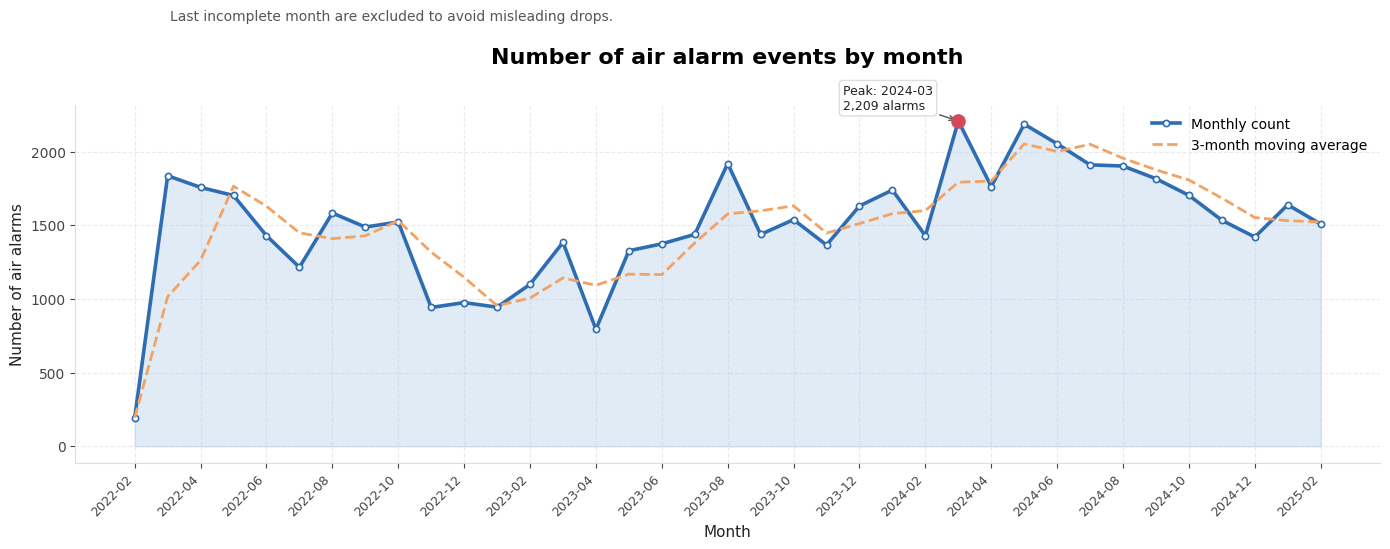

In [50]:
monthly_counts = df_plot.groupby("year_month").size().sort_index()
monthly_counts_plot = monthly_counts.iloc[:-1]

x_labels = monthly_counts_plot.index.astype(str).tolist()
y_values = monthly_counts_plot.values
x = np.arange(len(x_labels))
moving_avg = monthly_counts_plot.rolling(window=3, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(14, 5.8))
ax.fill_between(x, y_values, color=BLUE_SOFT, alpha=0.35)
ax.plot(
    x, y_values,
    color=BLUE_MAIN, linewidth=2.6,
    marker="o", markersize=4.5,
    markerfacecolor="white",
    markeredgewidth=1.2,
    label="Monthly count"
)

ax.plot(
    x, moving_avg,
    color=GOLD, linewidth=2,
    linestyle="--",
    label="3-month moving average"
)

peak_idx = int(np.argmax(y_values))
ax.scatter(x[peak_idx], y_values[peak_idx], s=90, color=RED_ACCENT, zorder=5)

ax.annotate(
    f"Peak: {x_labels[peak_idx]}\n{y_values[peak_idx]:,} alarms",
    xy=(x[peak_idx], y_values[peak_idx]),
    xytext=(x[peak_idx] - 3.5, y_values[peak_idx] + 80),
    arrowprops=dict(arrowstyle="->", color=TEXT_GREY),
    fontsize=9,
    color="#222222",
    bbox=dict(boxstyle="round", fc="white", ec="#DDDDDD")
)

tick_idx = np.arange(0, len(x_labels), 2)
ax.set_xticks(tick_idx)
ax.set_xticklabels([x_labels[i] for i in tick_idx], rotation=45, ha="right")

ax.set_title("Number of air alarm events by month", pad=30)
ax.set_xlabel("Month")
ax.set_ylabel("Number of air alarms")

ax.legend(frameon=False)

style_ax(ax, "both")
add_subtitle(fig, "Last incomplete month are excluded to avoid misleading drops.")

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

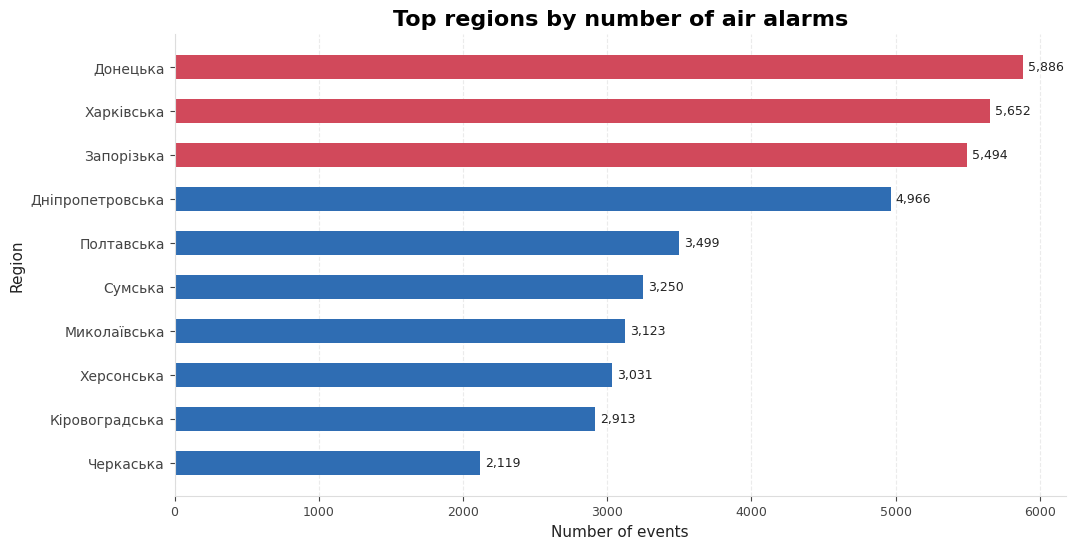

In [51]:
region_counts = df_plot.groupby("region_key").size().sort_values(ascending=False).head(10)

plot_region_counts = region_counts.sort_values()
top3_regions = set(region_counts.head(3).index)

bar_colors = [
    RED_ACCENT if region in top3_regions 
    else BLUE_MAIN for region in plot_region_counts.index
]

fig, ax = plt.subplots(figsize=(11.5, 6))

bars = ax.barh(
    plot_region_counts.index,
    plot_region_counts.values,
    color=bar_colors,
    height=0.55
)

for bar, value in zip(bars, plot_region_counts.values):
    ax.text(
        value + 35,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center",
        fontsize=9,
        color="#222222"
    )

ax.set_title("Top regions by number of air alarms")
ax.set_xlabel("Number of events")
ax.set_ylabel("Region")
style_ax(ax, "x")
plt.show()

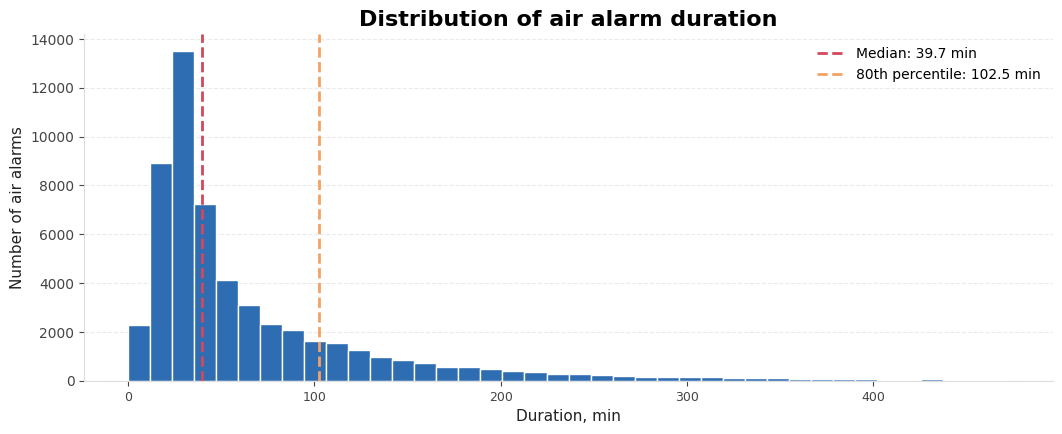

In [52]:
duration_min = df_plot["duration_min"].copy()
p99 = duration_min.quantile(0.99)
p80 = duration_min.quantile(0.80)
median_val = duration_min.median()

dur_clipped = duration_min[duration_min <= p99]

fig, ax = plt.subplots(figsize=(12.5, 4.5))

ax.hist(
    dur_clipped,
    bins=40,
    color=BLUE_MAIN,
    edgecolor="white"
)

ax.axvline(median_val, color=RED_ACCENT, linestyle="--", linewidth=2, label=f"Median: {median_val:.1f} min")
ax.axvline(p80, color=GOLD, linestyle="--", linewidth=2, label=f"80th percentile: {p80:.1f} min")

ax.set_title("Distribution of air alarm duration")
ax.set_xlabel("Duration, min")
ax.set_ylabel("Number of air alarms")
style_ax(ax, "y")
ax.legend(frameon=False, loc="upper right")
plt.show()

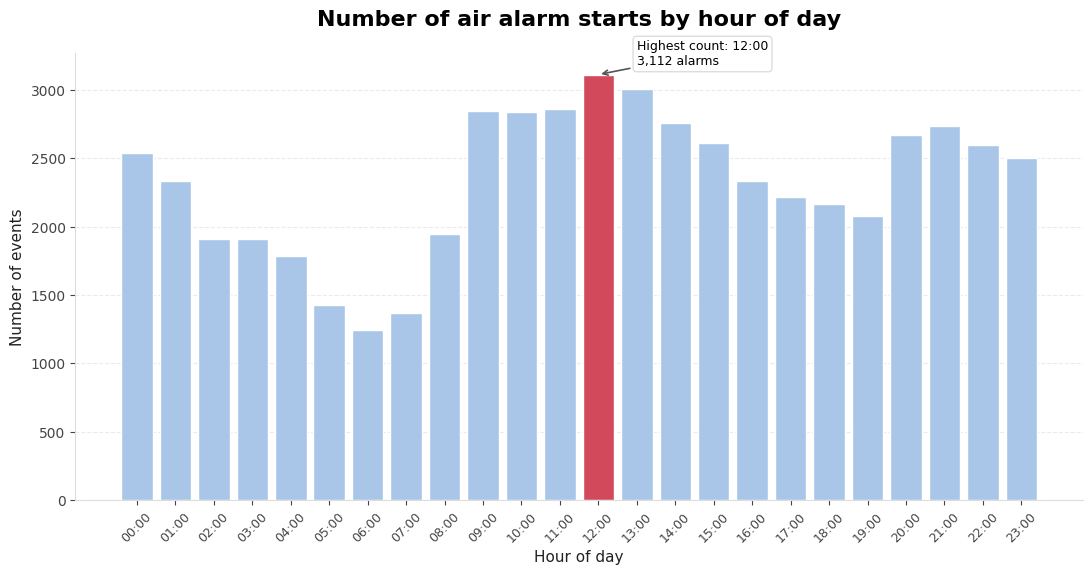

In [53]:
hour_counts = df_plot.groupby("hour").size()

top_hour = hour_counts.idxmax()
hour_colors = [BLUE_SOFT] * 24
hour_colors[top_hour] = RED_ACCENT

fig, ax = plt.subplots(figsize=(13, 5.8))
bars = ax.bar(
    hour_counts.index,
    hour_counts.values,
    color=hour_colors,
    edgecolor="white",
    width=0.82
)

ax.annotate(
    f"Highest count: {top_hour:02d}:00\n{hour_counts[top_hour]:,} alarms",
    xy=(top_hour, hour_counts[top_hour]),
    xytext=(top_hour + 1, hour_counts[top_hour] + 70),
    arrowprops=dict(arrowstyle="->", color=TEXT_GREY, lw=1.2),
    fontsize=9,
    bbox=dict(boxstyle="round", fc="white", ec="#DDDDDD")
)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)
ax.set_title("Number of air alarm starts by hour of day", pad=20)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Number of events")
style_ax(ax, "y")
plt.show()

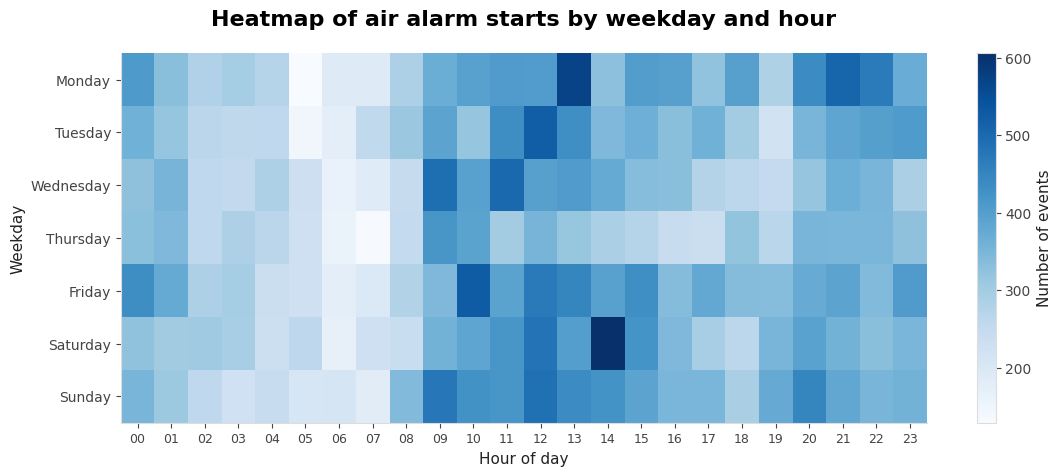

In [54]:
heatmap_data = (
    df_plot.groupby(["weekday", "hour"]).size()
    .reindex(pd.MultiIndex.from_product([weekday_order, range(24)]), fill_value=0)
    .unstack()
)

fig, ax = plt.subplots(figsize=(13, 4.8))
im = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap="Blues"
)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}" for h in range(24)])
ax.set_yticks(range(len(weekday_order)))
ax.set_yticklabels(weekday_order)

ax.set_title("Heatmap of air alarm starts by weekday and hour", pad=20)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Weekday")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of events")
plt.show()

### ISW

In [55]:
df_isw_raw.shape

(1467, 4)

In [56]:
df_isw_raw.head()

,date,title,url,text
0,2022-02-24,Russia-Ukraine Warning Update: Initial Russian...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...
1,2022-02-25,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...
2,2022-02-26,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...
3,2022-02-27,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...
4,2022-02-28,"Russian Offensive Campaign Assessment, Februar...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...


In [57]:
df_isw_raw.sample(5)

,date,title,url,text
292,2022-12-13,"Russian Offensive Campaign Assessment, Decembe...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
661,2023-12-17,"Russian Offensive Campaign Assessment, Decembe...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
784,2024-04-18,"Russian Offensive Campaign Assessment, April 1...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
924,2024-09-05,"Russian Offensive Campaign Assessment, Septemb...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
300,2022-12-21,"Russian Offensive Campaign Assessment, Decembe...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...


In [58]:
df_isw_raw.describe()

,date,title,url,text
count,1467,1467,1467,1467
unique,1467,1455,1455,1455
top,2026-03-01,None,None,None
freq,1,13,13,13


In [59]:
df_isw_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1467 entries, 0 to 1466
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    1467 non-null   object
 1   title   1467 non-null   object
 2   url     1467 non-null   object
 3   text    1467 non-null   object
dtypes: object(4)
memory usage: 46.0+ KB


All columns currently have the `object` data type. 

In [60]:
df_isw = df_isw_raw.copy()

In [61]:
for col in ["date","title", "url", "text"]:
    df_isw[col] = df_isw[col].replace("None", np.nan)

In [62]:
df_isw["date"] = pd.to_datetime(df_isw["date"], errors="coerce")
print("Invalid dates:", df_isw["date"].isna().sum())
print(df_isw["date"].dtype)

Invalid dates: 0
datetime64[ns]


In [63]:
outside_range = df_isw[(df_isw["date"] < "2022-02-24") | (df_isw["date"] > "2026-03-01")]
print(outside_range)

Empty DataFrame
Columns: [date, title, url, text]
Index: []


In [64]:
print("Missing values:", df_isw.isna().sum())

Missing values: date      0
title    13
url      13
text     13
dtype: int64


In [65]:
print("Duplicate dates:", df_isw["date"].duplicated().sum())
print("Duplicate non-missing titles:", df_isw["title"].dropna().duplicated().sum())
print("Duplicate non-missing urls:", df_isw["url"].dropna().duplicated().sum())
print("Duplicate non-missing text:", df_isw["text"].dropna().duplicated().sum())
print("Duplicate full rows:", df_isw.duplicated().sum())

Duplicate dates: 0
Duplicate non-missing titles: 0
Duplicate non-missing urls: 0
Duplicate non-missing text: 0
Duplicate full rows: 0


In [66]:
dup_dates = df_isw[df_isw["date"].duplicated(keep=False)]
dup_dates[["date", "title", "url"]]

,date,title,url


In [67]:
df_isw = df_isw.dropna(subset=["title", "url", "text"]).copy()

In [68]:
print("Missing values:", df_isw.isna().sum())

Missing values: date     0
title    0
url      0
text     0
dtype: int64


In [69]:
def clean_isw_text(text):
    text = str(text)
    text = text.replace("Previous\nNext", " ")
    text = text.replace("Click\nhere", " ")
    text = text.replace("\n", " ")
    return text

df_isw["text_clean"] = df_isw["text"].apply(clean_isw_text)

In [70]:
df_isw["text"] = df_isw["text_clean"]
df_isw = df_isw.drop(columns=["text_clean"])

In [71]:
df_isw.head()

,date,title,url,text
0,2022-02-24,Russia-Ukraine Warning Update: Initial Russian...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Initial Russi...
1,2022-02-25,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
2,2022-02-26,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
3,2022-02-27,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
4,2022-02-28,"Russian Offensive Campaign Assessment, Februar...",https://understandingwar.org/research/russia-u...,"Russian Offensive Campaign Assessment, Febru..."


In [72]:
df_isw_plot = df_isw.copy()

df_isw_plot["year"] = df_isw_plot["date"].dt.year
df_isw_plot["year_month"] = df_isw_plot["date"].dt.to_period("M")
df_isw_plot["word_count"] = df_isw_plot["text"].str.split().str.len()
df_isw_plot["char_count"] = df_isw_plot["text"].str.len()

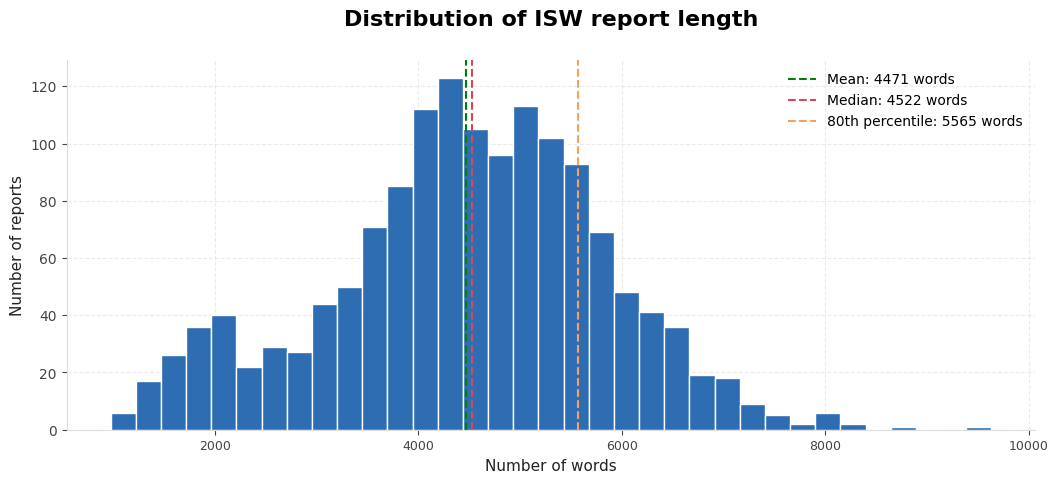

In [73]:
word_count = df_isw_plot["word_count"].copy()

p80 = word_count.quantile(0.80)
median_val = word_count.median()
mean_val = word_count.mean()

fig, ax = plt.subplots(figsize=(12.5, 4.8))
ax.hist(word_count, bins=35, color=BLUE_MAIN,edgecolor="white")

ax.axvline(
    mean_val,
    color="green",
    linestyle="--",
    label=f"Mean: {mean_val:.0f} words"
)
ax.axvline(
    median_val,
    color=RED_ACCENT,
    linestyle="--",
    label=f"Median: {median_val:.0f} words"
)
ax.axvline(
    p80,
    color=GOLD,
    linestyle="--",
    label=f"80th percentile: {p80:.0f} words"
)

ax.set_title("Distribution of ISW report length", pad=25)
ax.set_xlabel("Number of words")
ax.set_ylabel("Number of reports")
style_ax(ax, "both")
ax.legend(frameon=False, loc="upper right")
plt.show()

Distribution is not perfectly symmetric and appears to have tails on both sides, with most reports concentrated between roughly 4000 and 5500 words. 80% of reports are shorter than 5565 words.

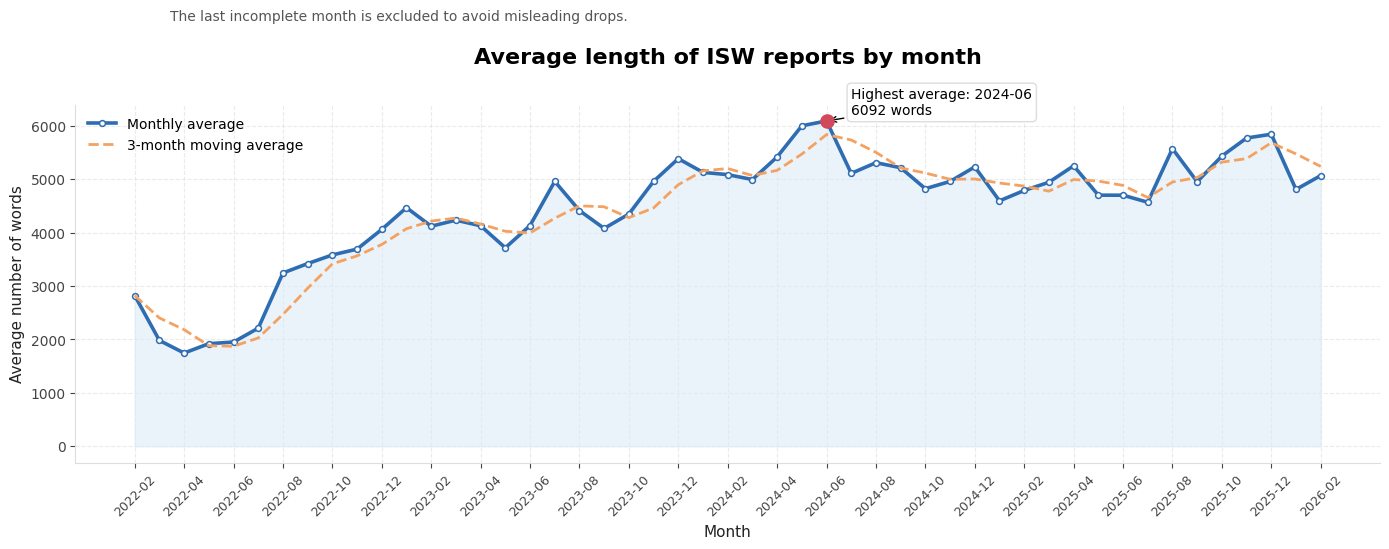

In [74]:
monthly_avg_words = df_isw_plot.groupby("year_month")["word_count"].mean().sort_index()
monthly_avg_words_plot = monthly_avg_words.iloc[:-1]

x_labels = monthly_avg_words_plot.index.astype(str).tolist()
y_values = monthly_avg_words_plot.values
x = np.arange(len(x_labels))
moving_avg = monthly_avg_words_plot.rolling(window=3, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(14, 5.8))
ax.fill_between(x, y_values, color=BLUE_LIGHT, alpha=0.55)
ax.plot(
    x, y_values,
    color=BLUE_MAIN, linewidth=2.6,
    marker="o", markersize=4.2,
    markerfacecolor="white",
    markeredgewidth=1.1,
    label="Monthly average"
)

ax.plot(
    x, moving_avg,
    color=GOLD, linewidth=2,
    linestyle="--",
    label="3-month moving average"
)

peak_idx = int(np.argmax(y_values))
ax.scatter(x[peak_idx], y_values[peak_idx], s=90, color=RED_ACCENT, zorder=5)
ax.annotate(
    f"Highest average: {x_labels[peak_idx]}\n{y_values[peak_idx]:.0f} words",
    xy=(x[peak_idx], y_values[peak_idx]),
    xytext=(max(0, x[peak_idx] + 1), y_values[peak_idx] + 120),
    arrowprops=dict(arrowstyle="->"),
    bbox=dict(boxstyle="round", fc="white", ec="#DDDDDD")
)

tick_idx = np.arange(0, len(x_labels), 2)
ax.set_xticks(tick_idx)
ax.set_xticklabels([x_labels[i] for i in tick_idx], rotation=45)

ax.set_title("Average length of ISW reports by month", pad=30)
ax.set_xlabel("Month")
ax.set_ylabel("Average number of words")

ax.legend(frameon=False)
style_ax(ax, "both")
add_subtitle(fig, "The last incomplete month is excluded to avoid misleading drops.")
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

Line chart shows that the average report length was lower in 2022 and became higher and more stable in later periods.

### Telegram 

In [75]:
df_tg_raw.shape

(129477, 3)

In [76]:
df_tg_raw.head()

,date,channel,message
0,2026-03-06 11:06:58+00:00,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...
1,2026-03-06 10:57:29+00:00,DeepStateUA,**🇺🇦**** Другий день обміну: додому **[**повер...
2,2026-03-06 06:32:47+00:00,DeepStateUA,🤬 **Угорщина затримала інкасаторські автомобіл...
3,2026-03-05 14:46:58+00:00,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...
4,2026-03-05 13:46:39+00:00,DeepStateUA,📋 **Зачистка з боку Сил Оборони на стику Запор...


In [77]:
df_tg_raw.sample(5)

,date,channel,message
52653,2023-02-10 10:50:04+00:00,UkraineNow,**Ворожа атака у п'ятницю — наслідки для інфра...
46139,2023-08-11 10:30:38+00:00,UkraineNow,**Під час останньої атаки ворог завдав ракетно...
49670,2023-05-07 17:25:29+00:00,UkraineNow,Завершується цей тиждень – дуже плідний для Ук...
71736,2022-03-07 13:20:30+00:00,UkraineNow,[​​](https://telegra.ph/file/01f57815ccd332f01...
33644,2024-06-01 05:48:27+00:00,UkraineNow,**Вранці окупанти вдарили по Балаклії: 12 пост...


In [78]:
df_tg_raw.describe()

,date,channel,message
count,129477,129477,129477
unique,129333,3,107432
top,2025-10-23 03:28:04+00:00,UkraineNow,📢 Відбій загрози.
freq,6,61363,929


In [79]:
df_tg_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129477 entries, 0 to 129476
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   date     129477 non-null  object
 1   channel  129477 non-null  object
 2   message  129477 non-null  object
dtypes: object(3)
memory usage: 3.0+ MB


In [80]:
print("Unique channels:", df_tg_raw["channel"].nunique())
print(df_tg_raw["channel"].value_counts())

Unique channels: 3
channel
UkraineNow     61363
kpszsu         56272
DeepStateUA    11842
Name: count, dtype: int64


In [81]:
print("Duplicate rows:",
      df_tg_raw.duplicated(subset=["date", "channel", "message"]).sum())

print("Duplicate messages:",
      df_tg_raw.duplicated(subset=["message"]).sum())

Duplicate rows: 0
Duplicate messages: 22045


In [82]:
df_tg = df_tg_raw.copy()

In [83]:
df_tg["date"] = pd.to_datetime(df_tg["date"], utc=True, errors="coerce")
df_tg["date"] = df_tg["date"].dt.tz_convert("Europe/Kyiv")
df_tg["date"] = df_tg["date"].dt.tz_localize(None)

print("Invalid dates:", df_tg["date"].isna().sum())
print(df_tg["date"].dtype)

Invalid dates: 0
datetime64[ns]


In [84]:
print("Min date:", df_tg["date"].min())
print("Max date:", df_tg["date"].max())

Min date: 2022-02-24 05:51:12
Max date: 2026-03-06 18:49:21


In [85]:
df_tg["message"] = df_tg["message"].astype(str)

print("Empty messages:", (df_tg["message"] == "").sum())
print("Whitespace messages:", df_tg["message"].str.strip().eq("").sum())

print("\nShortest messages:")
print(df_tg.loc[df_tg["message"].str.len().nsmallest(10).index, ["channel", "date", "message"]])

Empty messages: 0
Whitespace messages: 0

Shortest messages:
           channel                date message
1218   DeepStateUA 2025-06-01 14:49:49       🕸
4052   DeepStateUA 2024-02-16 14:20:06       🥪
7472   DeepStateUA 2022-11-11 13:10:16       🍉
9531   DeepStateUA 2022-04-12 21:46:52       😎
9804   DeepStateUA 2022-04-01 07:39:05       😳
10044  DeepStateUA 2022-03-22 18:42:05       💸
10163  DeepStateUA 2022-03-17 23:02:54       😐
10670  DeepStateUA 2022-03-04 18:47:06       🤨
10683  DeepStateUA 2022-03-04 14:53:13       🍾
10798  DeepStateUA 2022-03-03 09:02:20       🔴


In [86]:
CHANNEL_COLORS = {
    "UkraineNow": "green" ,
    "kpszsu": GOLD,
    "DeepStateUA": BLUE_DARK
}

In [87]:
df_tg["time"] = df_tg["date"].dt.strftime("%H:%M:%S")
df_tg["hour"] = df_tg["date"].dt.hour
df_tg["year_month"] = df_tg["date"].dt.to_period("M")
df_tg["date_day"] = df_tg["date"].dt.floor("D")

In [88]:
df_tg

,date,channel,message,time,hour,year_month,date_day
0,2026-03-06 13:06:58,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...,13:06:58,13,2026-03,2026-03-06
1,2026-03-06 12:57:29,DeepStateUA,**🇺🇦**** Другий день обміну: додому **[**повер...,12:57:29,12,2026-03,2026-03-06
2,2026-03-06 08:32:47,DeepStateUA,🤬 **Угорщина затримала інкасаторські автомобіл...,08:32:47,8,2026-03,2026-03-06
3,2026-03-05 16:46:58,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...,16:46:58,16,2026-03,2026-03-05
4,2026-03-05 15:46:39,DeepStateUA,📋 **Зачистка з боку Сил Оборони на стику Запор...,15:46:39,15,2026-03,2026-03-05
...,...,...,...,...,...,...,...
129472,2022-02-25 09:45:10,kpszsu,Вибухи на аеродромі Міллєрово в Ростовській об...,09:45:10,9,2022-02,2022-02-25
129473,2022-02-25 09:43:53,kpszsu,🛩🛩🛩🛩\nДо строю авіації Повітряних Сил Збройних...,09:43:53,9,2022-02,2022-02-25
129474,2022-02-25 00:43:47,kpszsu,ПОВІТРЯНІ СИЛИ ЗАВДАЛИ ВОРОГУ СУТТЄВИХ ВТРАТ\n...,00:43:47,0,2022-02,2022-02-25
129475,2022-02-25 00:43:23,kpszsu,https://fb.watch/bnMUkUvwfp/,00:43:23,0,2022-02,2022-02-25


In [89]:
df_tg_plot = df_tg.copy()

In [90]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]
df_tg_plot["weekday"] = pd.Categorical(
    df_tg_plot["date"].dt.day_name(),
    categories=weekday_order,
    ordered=True
)

df_tg_plot["message_len"] = df_tg_plot["message"].str.len()
df_tg_plot["word_count"] = df_tg_plot["message"].str.split().str.len()
df_tg_plot["is_duplicate_message"] = df_tg_plot.duplicated(subset=["message"], keep=False)

df_tg_plot.head()

,date,channel,message,time,hour,year_month,date_day,weekday,message_len,word_count,is_duplicate_message
0,2026-03-06 13:06:58,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...,13:06:58,13,2026-03,2026-03-06,Friday,606,42,False
1,2026-03-06 12:57:29,DeepStateUA,**🇺🇦**** Другий день обміну: додому **[**повер...,12:57:29,12,2026-03,2026-03-06,Friday,1171,116,False
2,2026-03-06 08:32:47,DeepStateUA,🤬 **Угорщина затримала інкасаторські автомобіл...,08:32:47,8,2026-03,2026-03-06,Friday,1477,140,False
3,2026-03-05 16:46:58,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...,16:46:58,16,2026-03,2026-03-05,Thursday,669,44,False
4,2026-03-05 15:46:39,DeepStateUA,📋 **Зачистка з боку Сил Оборони на стику Запор...,15:46:39,15,2026-03,2026-03-05,Thursday,1740,208,False


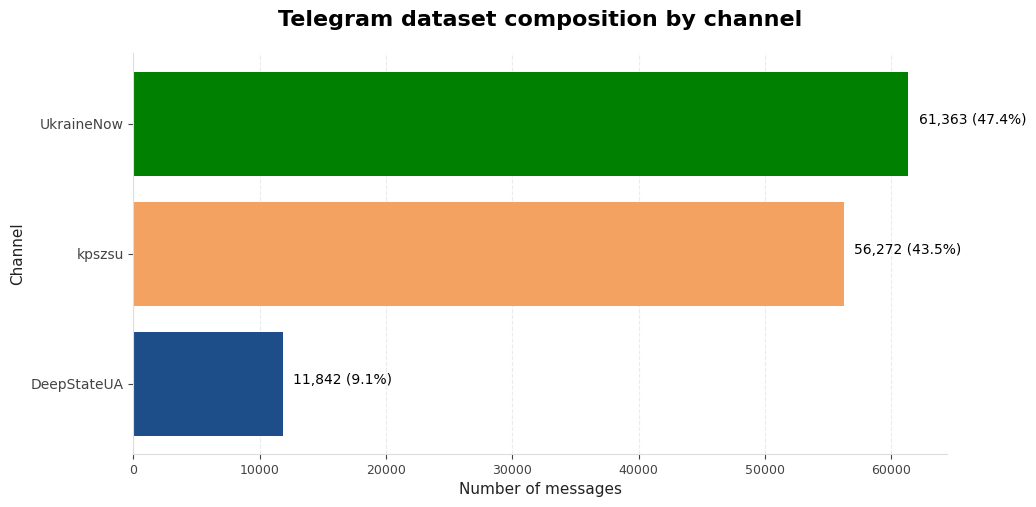

In [91]:
channel_counts = df_tg_plot["channel"].value_counts().sort_values()
channel_counts_percent = channel_counts / channel_counts.sum() * 100 

bar_colors = [CHANNEL_COLORS[channel] for channel in channel_counts.index]
fig, ax = plt.subplots(figsize=(10.5, 5.2))
bars = ax.barh(
    channel_counts.index,
    channel_counts.values,
    color=bar_colors,
)

for bar, count, share in zip(bars, channel_counts.values, channel_counts_percent.values):
    ax.text(
        count + 800,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({share:.1f}%)",
        fontsize=10
    )

ax.set_title("Telegram dataset composition by channel", pad=20)
ax.set_xlabel("Number of messages")
ax.set_ylabel("Channel")
style_ax(ax, "x")
plt.show()

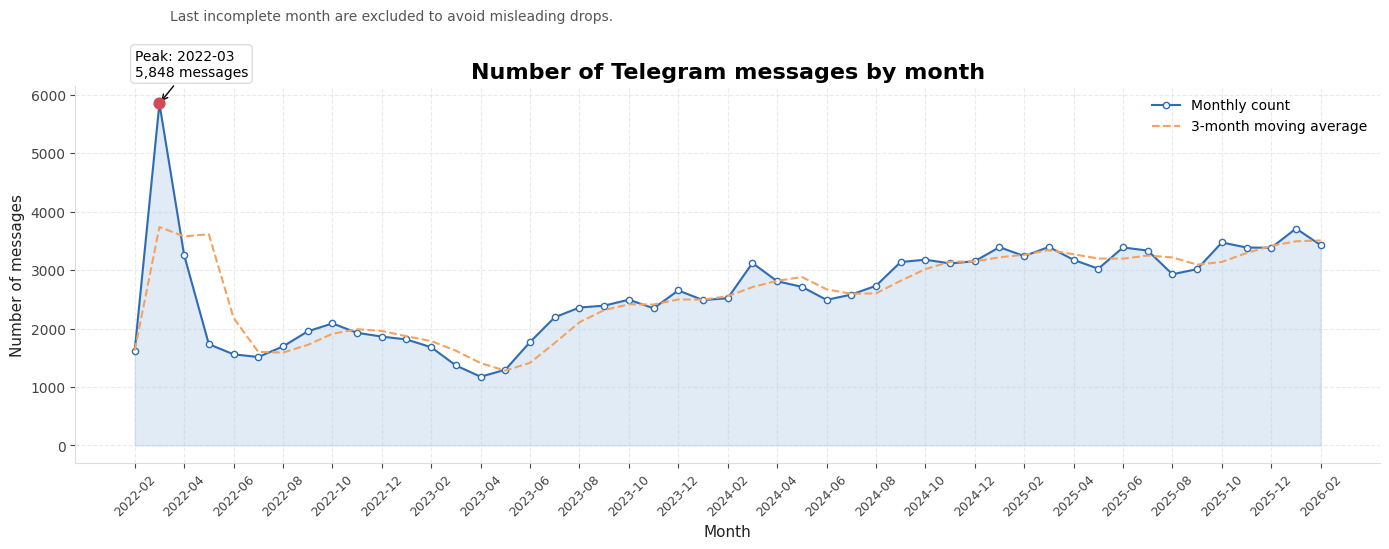

In [92]:
monthly_total = (df_tg_plot.groupby("year_month").size())

last_day = df_tg_plot["date"].max()
last_month_complete = last_day.day == last_day.days_in_month
if last_month_complete:
    monthly_total_plot = monthly_total.copy()
else:
    monthly_total_plot = monthly_total.iloc[:-1]

x_labels = monthly_total_plot.index.astype(str).tolist()
y_values = monthly_total_plot.values
x = np.arange(len(x_labels))
moving_avg = monthly_total_plot.rolling(window=3, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(14, 5.8))
ax.fill_between(x, y_values, color=BLUE_SOFT, alpha=0.35)
ax.plot(
    x, y_values,
    color=BLUE_MAIN,
    marker="o", markersize=4.5,
    markerfacecolor="white",
    label="Monthly count"
)
ax.plot(
    x, moving_avg,
    color=GOLD,
    linestyle="--",
    label="3-month moving average"
)

peak_idx = int(np.argmax(y_values))
ax.scatter(x[peak_idx], y_values[peak_idx], s=60, color=RED_ACCENT, zorder=5)
ax.annotate(
    f"Peak: {x_labels[peak_idx]}\n{y_values[peak_idx]:,} messages",
    xy=(x[peak_idx], y_values[peak_idx]),
    xytext=(max(0, x[peak_idx] - 4), y_values[peak_idx] + y_values.max() * 0.08),
    arrowprops=dict(arrowstyle="->"),
    bbox=dict(boxstyle="round", fc="white", ec="#DDDDDD")
)

tick_idx = np.arange(0, len(x_labels), 2)
ax.set_xticks(tick_idx)
ax.set_xticklabels([x_labels[i] for i in tick_idx], rotation=45)

ax.set_title("Number of Telegram messages by month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of messages")
ax.legend(frameon=False)
add_subtitle(fig, "Last incomplete month are excluded to avoid misleading drops.")
style_ax(ax, "both")
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

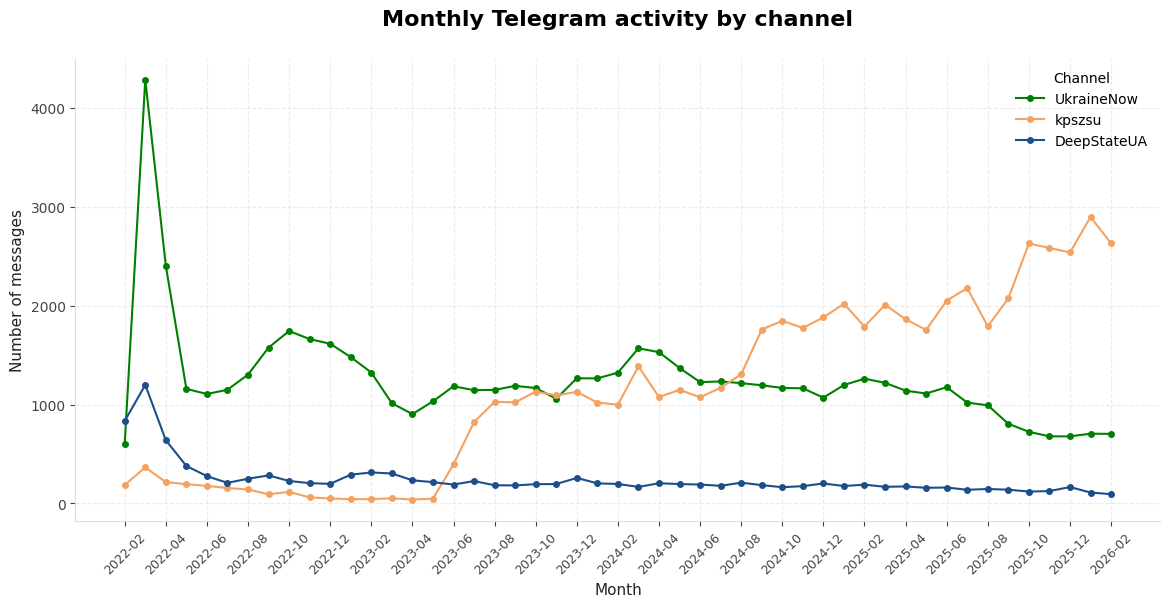

In [93]:
monthly_by_channel = (
    df_tg_plot.groupby(["year_month", "channel"])
    .size()
    .reset_index(name="messages_count")
)

if not last_month_complete:
    monthly_by_channel = monthly_by_channel[
        monthly_by_channel["year_month"] != monthly_by_channel["year_month"].max()
    ].copy()

monthly_by_channel["year_month_str"] = monthly_by_channel["year_month"].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))

for channel in ["UkraineNow", "kpszsu", "DeepStateUA"]:
    temp = monthly_by_channel[monthly_by_channel["channel"] == channel]
    ax.plot(
        temp["year_month_str"],
        temp["messages_count"],
        label=channel,
        color=CHANNEL_COLORS[channel],
        marker="o",
        markersize=4
    )

tick_idx = np.arange(0, monthly_by_channel["year_month_str"].nunique(), 2)
unique_months = monthly_by_channel["year_month_str"].drop_duplicates().tolist()

ax.set_xticks(tick_idx)
ax.set_xticklabels([unique_months[i] for i in tick_idx], rotation=45)
ax.set_title("Monthly Telegram activity by channel", pad=24)
ax.set_xlabel("Month")
ax.set_ylabel("Number of messages")
ax.legend(title="Channel", frameon=False)
style_ax(ax, "both")
plt.show()

C:\Users\vikam\AppData\Local\Temp\ipykernel_4976\790425606.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tg_plot.groupby(["weekday", "hour"])


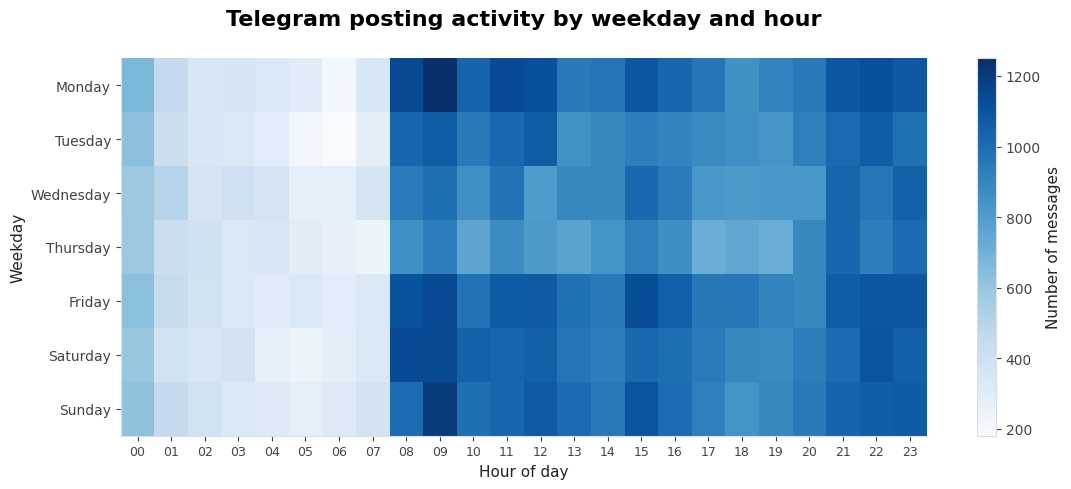

In [94]:
heatmap_data = (
    df_tg_plot.groupby(["weekday", "hour"])
    .size()
    .reindex(pd.MultiIndex.from_product([weekday_order, range(24)]), fill_value=0)
    .unstack()
)

fig, ax = plt.subplots(figsize=(13, 4.9))
im = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap="Blues"
)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}" for h in range(24)])
ax.set_yticks(range(len(weekday_order)))
ax.set_yticklabels(weekday_order)

ax.set_title("Telegram posting activity by weekday and hour", pad=24)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Weekday")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of messages")
plt.show()

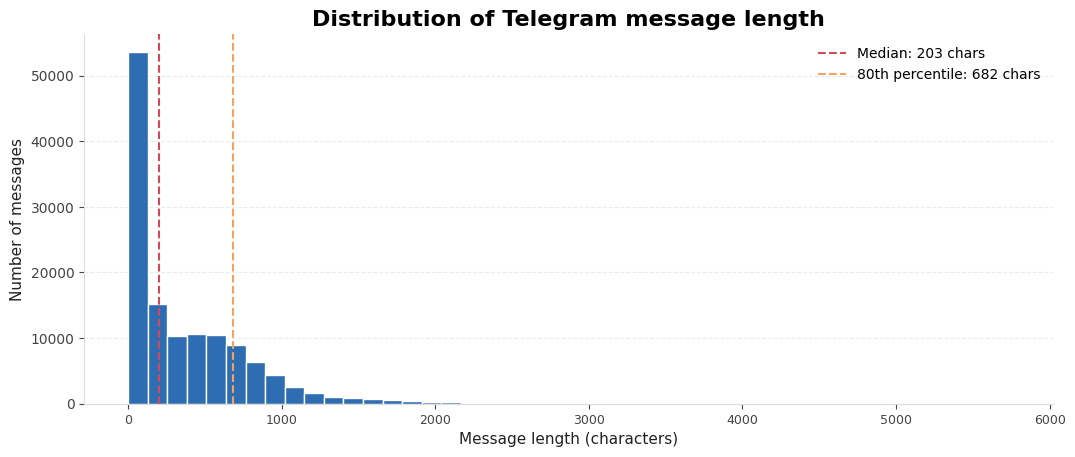

In [95]:
message_len = df_tg_plot["message_len"].copy()

p80 = message_len.quantile(0.80)
median_val = message_len.median()

fig, ax = plt.subplots(figsize=(12.5, 4.8))
ax.hist(
    message_len,
    bins=45,
    color=BLUE_MAIN,
    edgecolor="white",
)

ax.axvline(
    median_val,
    color=RED_ACCENT,
    linestyle="--",
    label=f"Median: {median_val:.0f} chars"
)

ax.axvline(
    p80,
    color=GOLD,
    linestyle="--",
    label=f"80th percentile: {p80:.0f} chars"
)

ax.set_title("Distribution of Telegram message length")
ax.set_xlabel("Message length (characters)")
ax.set_ylabel("Number of messages")
ax.legend(frameon=False, loc="upper right")
style_ax(ax, "y")
plt.show()

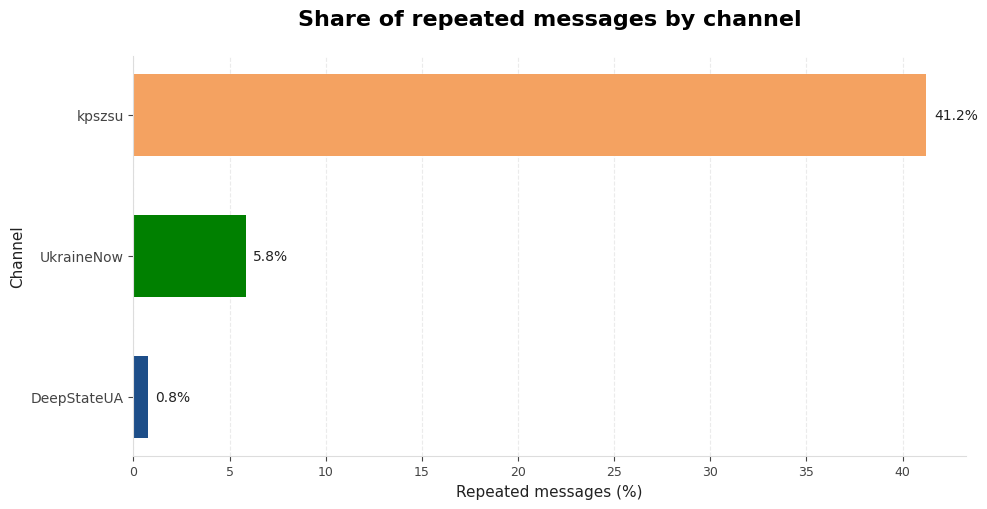

In [96]:
dup_share = (
    df_tg_plot.groupby("channel")["is_duplicate_message"]
    .mean()
    .mul(100)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5.2))

bars = ax.barh(
    dup_share.index,
    dup_share.values,
    color=[CHANNEL_COLORS[ch] for ch in dup_share.index],
    height=0.58
)

for bar, value in zip(bars, dup_share.values):
    ax.text(
        value + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=10,
        color="#222222"
    )

ax.set_title("Share of repeated messages by channel", pad=22)
ax.set_xlabel("Repeated messages (%)")
ax.set_ylabel("Channel")

style_ax(ax, "x")
plt.tight_layout()
plt.show()

## IV. Prepare data

### ISW

In [97]:
df_isw.head()

,date,title,url,text
0,2022-02-24,Russia-Ukraine Warning Update: Initial Russian...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Initial Russi...
1,2022-02-25,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
2,2022-02-26,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
3,2022-02-27,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
4,2022-02-28,"Russian Offensive Campaign Assessment, Februar...",https://understandingwar.org/research/russia-u...,"Russian Offensive Campaign Assessment, Febru..."


In [98]:
df_isw['text'] = df_isw['text'].str.lower()

In [99]:
df_isw['text'] = df_isw['text'].str.replace(f"[{string.punctuation}]", "", regex=True)

1. Підготовка

In [100]:
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))
isw_word_cache = {}

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\vikam\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [101]:
def smart_preprocess_cached(text):
    text = str(text).lower()

    # Очистка
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s-]', ' ', text)
    text = re.sub(r'\b\d+\b', '', text)

    words = text.split()
    clean_words = []

    for w in words:
        # ПЕРЕВІРКА СТОП-СЛІВ
        if w in stop_words or len(w) <= 2:
            continue

        # КЕШУВАННЯ ЛЕМАТИЗАЦІЇ
        if w not in isw_word_cache:
            isw_word_cache[w] = lemmatizer.lemmatize(w)

        clean_words.append(isw_word_cache[w])

    return " ".join(clean_words)

2. Застосування

In [102]:
tqdm.pandas()
print("Обробка текстів ISW...")
df_isw['text_final'] = df_isw['text'].progress_apply(smart_preprocess_cached)

Обробка текстів ISW...


100%|██████████████████████████████████████████████████████████████████████████████| 1454/1454 [00:24<00:00, 58.63it/s]


3. Векторизація

In [103]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=5)
X = vectorizer.fit_transform(df_isw['text_final'])

4. Результати

In [104]:
print(f"Розмірність матриці: {X.shape}")
feature_names = vectorizer.get_feature_names_out()
print("Перші 20 ознак (тепер точно слова):")
print(feature_names[:20])

Розмірність матриці: (1454, 5000)
Перші 20 ознак (тепер точно слова):
['abandoned' 'ability' 'able' 'abroad' 'accept' 'access' 'access isw'
 'according' 'account' 'accumulating' 'accusation' 'accused' 'accusing'
 'achieve' 'achieved' 'achieving' 'acknowledged' 'across' 'act' 'acting']


### Telegram

In [105]:
tqdm.pandas()
morph = pymorphy3.MorphAnalyzer(lang='uk')
word_cache = {}

def fast_tg_clean_optimized(text):
    text = re.sub(r'https?://\S+|@\w+', '', str(text).lower())
    text = re.sub(r'[^а-яіїєґa-z\s-]', ' ', text)
    words = text.split()

    res = []
    for w in words:
        if len(w) < 3: continue

        if w not in word_cache:
            word_cache[w] = morph.parse(w)[0].normal_form
        res.append(word_cache[w])

    return " ".join(res)

print("Починаю очистку ТГ (це займе пару хвилин)...")
df_tg['message_clean'] = df_tg['message'].progress_apply(fast_tg_clean_optimized)

Починаю очистку ТГ (це займе пару хвилин)...


100%|████████████████████████████████████████████████████████████████████████| 129477/129477 [01:01<00:00, 2095.63it/s]


In [106]:
vectorizer_tg = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    dtype=np.float32
)
X_tg = vectorizer_tg.fit_transform(df_tg['message_clean'])

print(X_tg.shape)

(129477, 5000)


### War events (alarms)

In [107]:
df_war_events.head()

,id,region_id,region_city,all_region,start,end,duration_min,region_key
0,52432,13.0,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28,129.183333,Львівська
1,53292,25.0,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43,191.000000,Чернігівська
2,52080,2.0,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42,30.000000,Вінницька
3,52857,20.0,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47,48.000000,Харківська
4,52700,19.0,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19,420.716667,Тернопільська


In [108]:
df_war_events = df_war_events[df_war_events["duration_min"] >= 0].copy()
print("Shape after removing negative durations:", df_war_events.shape)

Shape after removing negative durations: (55787, 8)


In [109]:
print("Negative durations:", (df_war_events["duration_min"] < 0).sum())

Negative durations: 0


In [110]:
rows = []

for row in df_war_events[["id", "region_id", "region_key", "start", "end"]].itertuples(index=False):
    start_hour = row.start.floor("h")
    end_hour = row.end.floor("h")

    for hour in pd.date_range(start_hour, end_hour, freq="h"):
        hour_end = hour + pd.Timedelta(hours=1)

        overlap_start = max(row.start, hour)
        overlap_end = min(row.end, hour_end)

        overlap_min = (overlap_end - overlap_start).total_seconds() / 60

        if overlap_min > 0:
            rows.append({
                "datetime_hour": hour,
                "region_id": row.region_id,
                "region_key": row.region_key,
                "alarm_minutes_in_hour": overlap_min,
                "alarm_active": 1,
                "alarm_id": row.id
            })

df_alarm_hourly = pd.DataFrame(rows)

df_alarm_hourly = (
    df_alarm_hourly
    .groupby(["datetime_hour", "region_id", "region_key"], as_index=False)
    .agg(
        alarm_minutes_in_hour=("alarm_minutes_in_hour", "sum"),
        alarm_active=("alarm_active", "max"),
        alarm_event_count=("alarm_id", "nunique")
    )
    .sort_values(["datetime_hour", "region_id"])
    .reset_index(drop=True)
)

df_alarm_hourly["alarm_minutes_in_hour"] = df_alarm_hourly["alarm_minutes_in_hour"].clip(0, 60)

df_alarm_hourly.head(50)


,datetime_hour,region_id,region_key,alarm_minutes_in_hour,alarm_active,alarm_event_count
0,2022-02-24 07:00:00,13.0,Львівська,16.716667,1,1
1,2022-02-24 08:00:00,13.0,Львівська,60.000000,1,1
2,2022-02-24 09:00:00,13.0,Львівська,52.466667,1,1
3,2022-02-24 14:00:00,25.0,Чернігівська,59.283333,1,1
4,2022-02-24 15:00:00,2.0,Вінницька,19.300000,1,1
5,2022-02-24 15:00:00,25.0,Чернігівська,60.000000,1,1
6,2022-02-24 16:00:00,2.0,Вінницька,10.700000,1,1
7,2022-02-24 16:00:00,25.0,Чернігівська,60.000000,1,1
8,2022-02-24 17:00:00,25.0,Чернігівська,11.716667,1,1
9,2022-02-24 20:00:00,20.0,Харківська,48.000000,1,1


In [111]:
all_hours = pd.date_range(
    weather["datetime_hour"].min(),
    weather["datetime_hour"].max(),
    freq="h"
)

regions_dim = (
    df_war_events[["region_id", "region_key"]]
    .drop_duplicates()
    .sort_values("region_id")
    .reset_index(drop=True)
)

backbone = (
    pd.MultiIndex.from_product(
        [all_hours, regions_dim["region_id"]],
        names=["datetime_hour", "region_id"]
    )
    .to_frame(index=False)
    .merge(regions_dim, on="region_id", how="left")
    .sort_values(["datetime_hour", "region_id"])
    .reset_index(drop=True)
)

df_alarm_hourly_full = backbone.merge(
    df_alarm_hourly,
    on=["datetime_hour", "region_id", "region_key"],
    how="left"
)

for col in ["alarm_minutes_in_hour", "alarm_active", "alarm_event_count"]:
    df_alarm_hourly_full[col] = df_alarm_hourly_full[col].fillna(0)

df_alarm_hourly_full["alarm_active"] = df_alarm_hourly_full["alarm_active"].astype(int)
df_alarm_hourly_full["alarm_event_count"] = df_alarm_hourly_full["alarm_event_count"].astype(int)

df_alarm_hourly_full["date"] = df_alarm_hourly_full["datetime_hour"].dt.floor("D")
df_alarm_hourly_full["hour"] = df_alarm_hourly_full["datetime_hour"].dt.hour
df_alarm_hourly_full["month"] = df_alarm_hourly_full["datetime_hour"].dt.month
df_alarm_hourly_full["weekday"] = df_alarm_hourly_full["datetime_hour"].dt.weekday

df_alarm_hourly_full.head(50)


,datetime_hour,region_id,region_key,alarm_minutes_in_hour,alarm_active,alarm_event_count,date,hour,month,weekday
0,2022-02-24 00:00:00,1.0,АР Крим,0.0,0,0,2022-02-24,0,2,3
1,2022-02-24 00:00:00,2.0,Вінницька,0.0,0,0,2022-02-24,0,2,3
2,2022-02-24 00:00:00,3.0,Волинська,0.0,0,0,2022-02-24,0,2,3
3,2022-02-24 00:00:00,4.0,Дніпропетровська,0.0,0,0,2022-02-24,0,2,3
4,2022-02-24 00:00:00,5.0,Донецька,0.0,0,0,2022-02-24,0,2,3
5,2022-02-24 00:00:00,6.0,Житомирська,0.0,0,0,2022-02-24,0,2,3
6,2022-02-24 00:00:00,7.0,Закарпатська,0.0,0,0,2022-02-24,0,2,3
7,2022-02-24 00:00:00,8.0,Запорізька,0.0,0,0,2022-02-24,0,2,3
8,2022-02-24 00:00:00,9.0,Івано-Франківська,0.0,0,0,2022-02-24,0,2,3
9,2022-02-24 00:00:00,10.0,Київська,0.0,0,0,2022-02-24,0,2,3


In [112]:
# df_war_events.to_csv("war_events_processed.csv", index=False, encoding="utf-8-sig")
# df_isw.to_csv("isw_processed.csv", index=False, encoding="utf-8-sig")
# df_tg.to_csv("telegram_processed.csv", index=False, encoding="utf-8-sig")
# weather.to_csv("weather_processed.csv", index=False, encoding="utf-8-sig")